# 15. 3Sum

Given an integer array nums, return all the triplets [nums[i], nums[j], nums[k]] such that i != j, i != k, and j != k, and nums[i] + nums[j] + nums[k] == 0.

Notice that the solution set must not contain duplicate triplets.

##  Example 1:

Input: nums = [-1,0,1,2,-1,-4]
Output: [[-1,-1,2],[-1,0,1]]
Explanation: 
nums[0] + nums[1] + nums[2] = (-1) + 0 + 1 = 0.
nums[1] + nums[2] + nums[4] = 0 + 1 + (-1) = 0.
nums[0] + nums[3] + nums[4] = (-1) + 2 + (-1) = 0.
The distinct triplets are [-1,0,1] and [-1,-1,2].
Notice that the order of the output and the order of the triplets does not matter.

## Example 2:

Input: nums = [0,1,1]
Output: []
Explanation: The only possible triplet does not sum up to 0.

## Example 3:

Input: nums = [0,0,0]
Output: [[0,0,0]]
Explanation: The only possible triplet sums up to 0.

# Specification

Dados um  array unidimensional de inteiros, temos que achar todas as combinações possiveis de tres valores que somados dão 0 e não pode repetir indice. Ou seja i != j != k , retornando um array de array com todas as combinações possíveis

```py
class Solution:
    class Solution:
        def threeSum(self, nums: List[int]) -> List[List[int]]:
            def complement(a:int,b:int)-> int:
                complement = -a-b
                return complement

```

## Edge case

- Cuidar com a ordem  das triplets por (i,j,k) e (k,j,i) ... representam a mesma coisa não pode repetir. 

# Plan 

- Uma solução ingênua seria fazer 3 for resultando em O(n^3) que é um algortimo muito lento para n grandes
- Pensei em uma lógica de complementos, dado um valor X árbitrátrio seu comeplemento seria o valor que o zera -x
- Podemos pensar que dados um (a+b) para ter um c que o zere c = (-a-b)
- Se iterarmos em for i e for j n^2 e anotar os seen podemos ver  se existe um complemento
- Podemos anotar as triplets (i,j,k) em triplets como um set para evitar duplicatas, onde k é um complemento 
- Iremos adicionar todos os elementos nums[j] já vistos, e assim podemos ver se existe um complemento que está dentro do set
- Para evitar repetição teremos que ordenar a lista antes de colocar no seen

In [1]:
from typing import List

class Solution:
    def threeSum(self, nums: List[int]) -> List[List[int]]:
        triplets = []
        n = len(nums)
        for i in range(n):
            for j in range(n):
                for k in range(n):
                    # All indices must be different
                    if i != j and j != k and i != k:
                        # Check if the sum is zero
                        if nums[i] + nums[j] + nums[k] == 0:
                            # Sort so order doesn't matter
                            triplet = [nums[i], nums[j], nums[k]].sort()
                            # Avoid duplicates
                            if triplet not in triplets:
                                triplets.append(triplet)
        return triplets

nums = [-1, 0, 1, 2, -1, -4]
print(Solution().threeSum(nums))

[None]


In [6]:
from typing import List


class Solution:
    def threeSum(self, nums: List[int]) -> List[List[int]]:
        n = len(nums)
        triplets = set()
        def complement_two_numbers(a,b):
            return -(a+b)
        for i in range(n):
            seen = set()
            for j in range(i + 1, n):
                complement = complement_two_numbers(nums[i],nums[j])
                if complement in seen:
                    item = [nums[i],nums[j],complement]
                    triplet = tuple(sorted(item))
                    triplets.add(triplet)
                seen.add(nums[j])
        return [list(t) for t in triplets]

    
nums = [-1, 0, 1, 2, -1, -4]
print(Solution().threeSum(nums))


[[-1, 0, 1], [-1, -1, 2]]


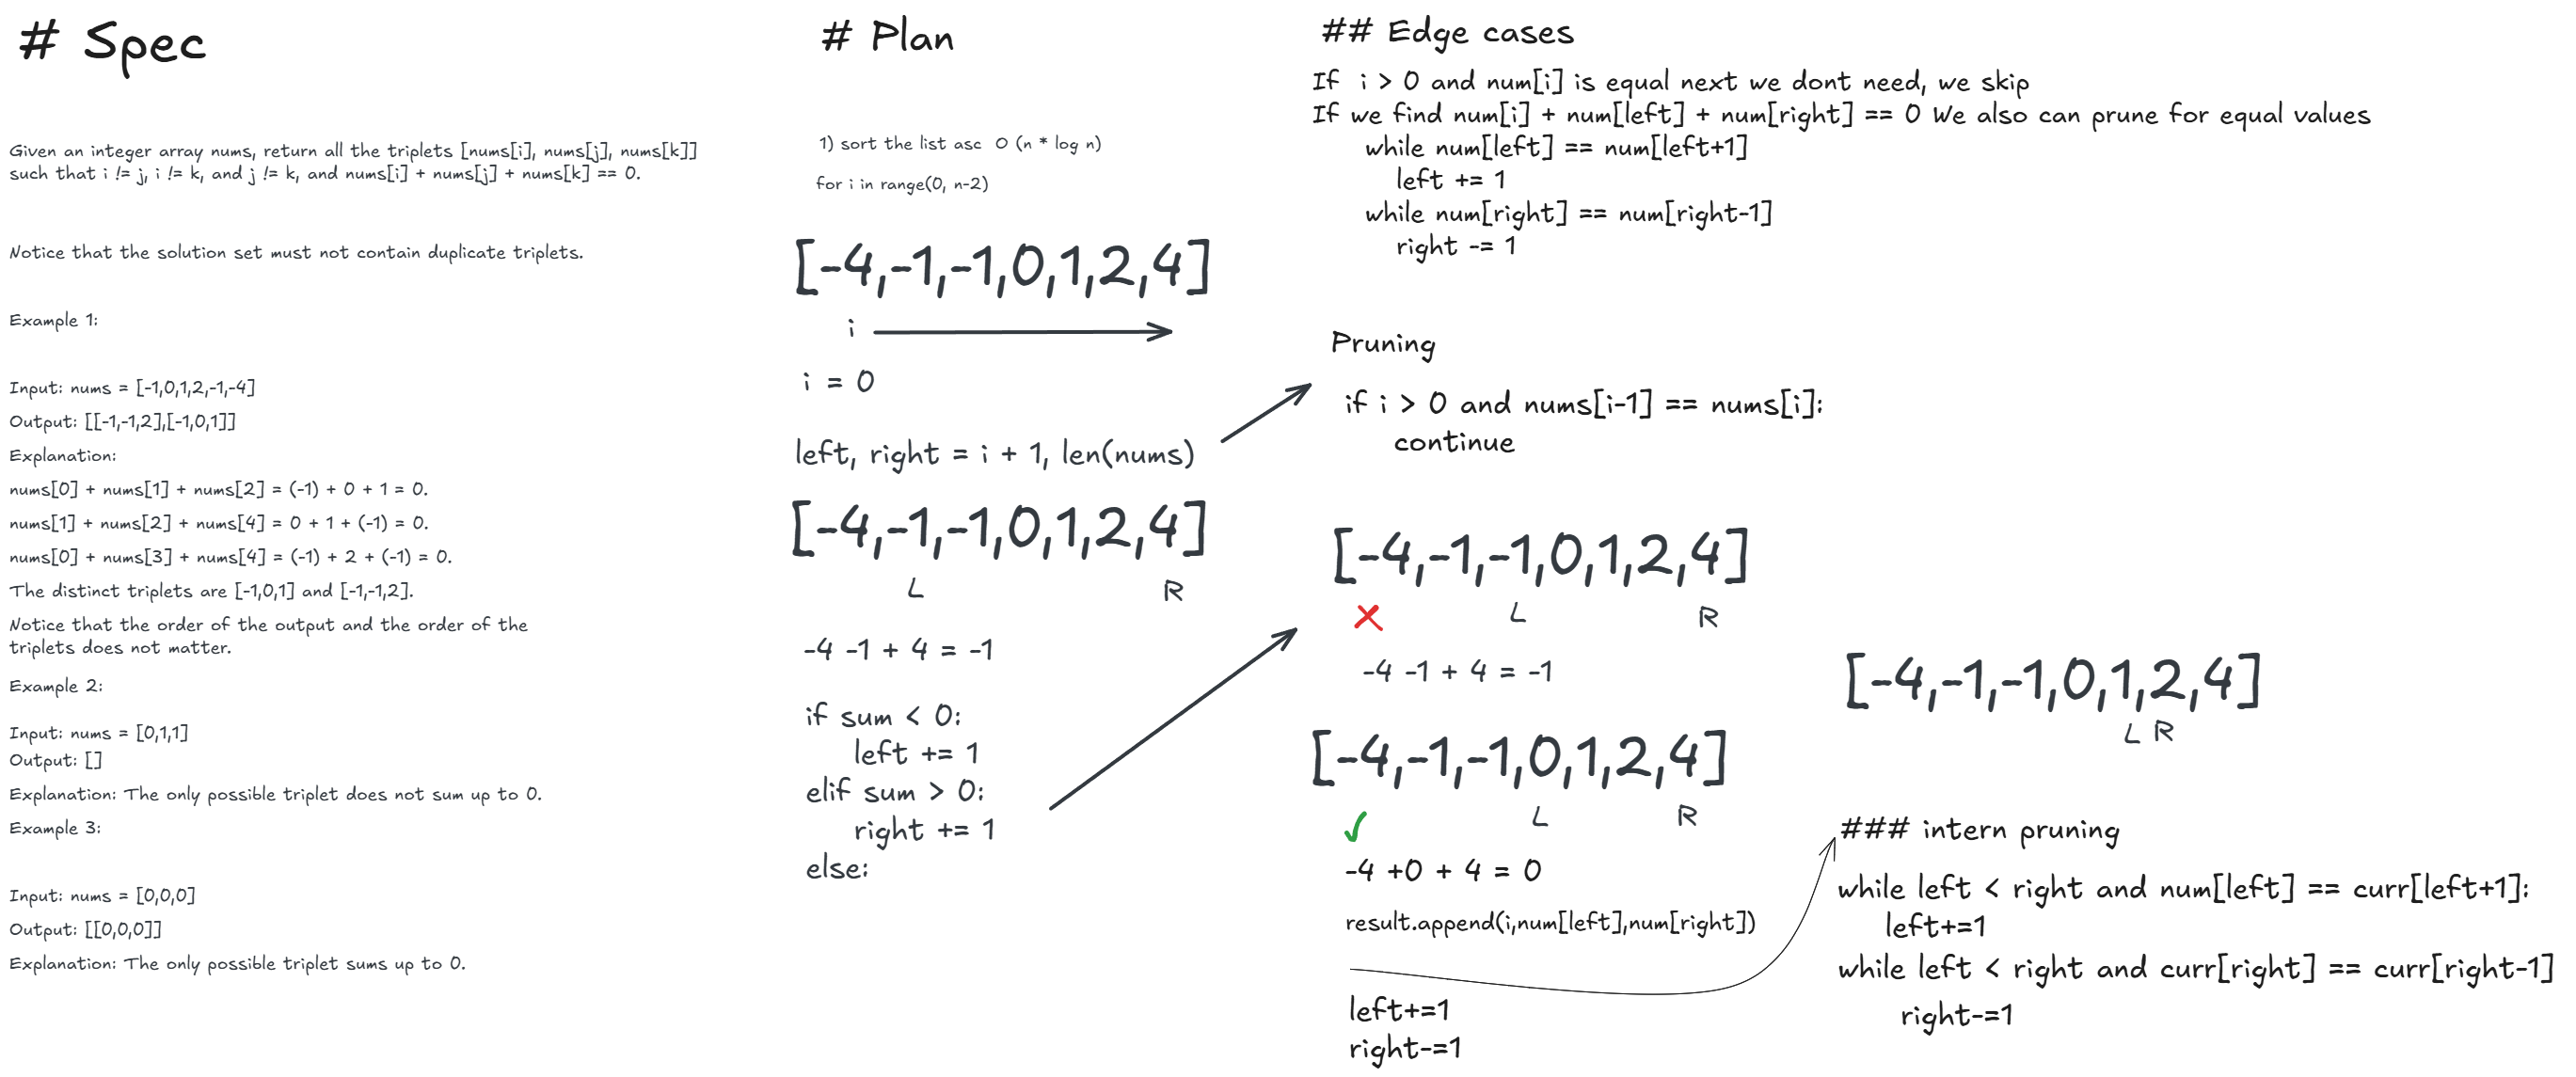

In [5]:
class Solution:
    def threeSum(self, nums: list[int]) -> list[list[int]]:
        nums.sort()
        n = len(nums)
        result = []

        for i in range(n - 2):
            if i > 0 and nums[i] == nums[i - 1]:
                continue

            left, right = i + 1, n - 1

            while left < right:
                total = nums[i] + nums[left] + nums[right]

                if total < 0:
                    left += 1
                elif total > 0:
                    right -= 1
                else:
                    result.append([nums[i], nums[left], nums[right]])

                    left += 1
                    right -= 1

                    while left < right and nums[left] == nums[left - 1]:
                        left += 1
                    while left < right and nums[right] == nums[right + 1]:
                        right -= 1

        return result
nums = [-1, 0, 1, 2, -1, -4]
print(Solution().threeSum(nums))

[[-1, -1, 2], [-1, 0, 1]]
